# Part 1 - Data Visualization and k-NN
In the first three parts, you will work with the GalaxyMNIST dataset. This dataset comprises images of galaxies coupled with class labels and we aim to build the best possible classifier.
In this first part you should get to know the data, implement a simple k-NN classifier and write your own evaluation. 

In [1]:
%load_ext autoreload
%autoreload 2

from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import torch, gzip, requests

# machine learning metrics
from sklearn import metrics

# performance metrics
from tqdm import tqdm
import time

from collections import Counter
from itertools import chain

# dataset
from galaxy_mnist import GalaxyMNIST

download_data = [
    {"url":"https://www.dropbox.com/scl/fi/l4ap5eq7z49l27dnfw076/train_dataset.hdf5.gz?rlkey=gjfrrrouoah0hbydbkpfx66as&st=tw6znd55&dl=1", "file":"train_dataset.hdf5"},
    {"url":"https://www.dropbox.com/scl/fi/ty43vhrrpa8cf8azn3awn/test_dataset.hdf5.gz?rlkey=jmlkzjiguhe271nbuzpa0njna&st=5oco8ika&dl=1",  "file":"test_dataset.hdf5"}
]

root = Path("raw_galaxy_mnist")
raw = root/"GalaxyMNIST"/"raw"
raw.mkdir(parents=True, exist_ok=True)
for d in download_data:
    p = raw/d["file"]
    if not p.exists():
        r = requests.get(d["url"], timeout=60)
        p.write_bytes(gzip.decompress(r.content))

dataset = GalaxyMNIST(root=root, train=True)
val_dataset = GalaxyMNIST(root=root, train=False)

In [2]:
# Extract data and targets
raw_images, labels = dataset.data, dataset.targets
raw_test_images, test_labels = val_dataset.data, val_dataset.targets
label_names = dataset.classes
label_count = len(dataset.classes)

# You can add here your analysis or visualization code
print(f"{raw_images.shape = }")
print(f"{raw_images.dtype = }")
print(f"{labels.shape = }")
print(f"{labels.dtype = }")
print(f"{test_labels.shape = }")
print(f"{test_labels.dtype = }")
print(f"{label_names = }")
print(f"{label_count = }")

raw_images.shape = torch.Size([8000, 3, 64, 64])
raw_images.dtype = torch.uint8
labels.shape = torch.Size([8000])
labels.dtype = torch.int64
test_labels.shape = torch.Size([2000])
test_labels.dtype = torch.int64
label_names = ['smooth_round', 'smooth_cigar', 'edge_on_disk', 'unbarred_spiral']
label_count = 4


## 1.1 Simple Data Visualization
- Write the code to plot N images per class.
- Describe in one sentence the apparent differences between the classes.
- Plot a histogram of pixel values of a single image (pixel value on x-axis, count on y-axis) and describe it.

In [3]:
def show_galaxy(image: torch.Tensor, ax, title: str = "") -> None:
    # permute image shape: (C, H, W) -> (H, W, C) for matplotlib
    img = image.permute(1, 2, 0)

    # normalize to [0, 1]
    img = img / 255

    # display
    ax.imshow(img)
    ax.set_title(title)
    ax.axis("off")
    return


def show_first_galaxies_of_class(N: int, images: torch.Tensor, label_name: str, cols: int = 3) -> None:
    rows: int = (N - 1) // cols + 1
    fig, axes = plt.subplots(rows, cols, figsize=(3 * cols, 3 * rows))
    axes = axes.flatten()

    fig.suptitle(f"Class: {label_name}")
    for i in range(N):
        show_galaxy(images[i], axes[i])
    for j in range(N, len(axes)):
        axes[j].set_visible(False)

    plt.show(fig)
    return

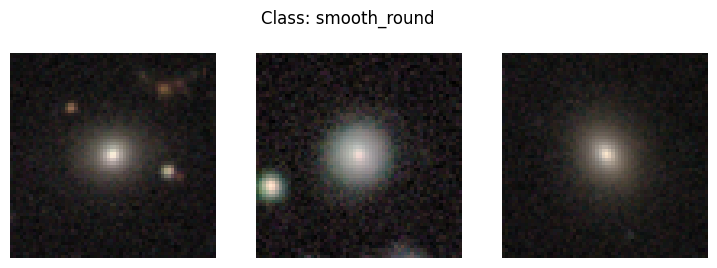

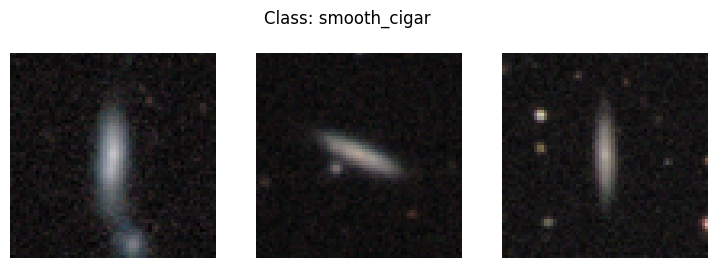

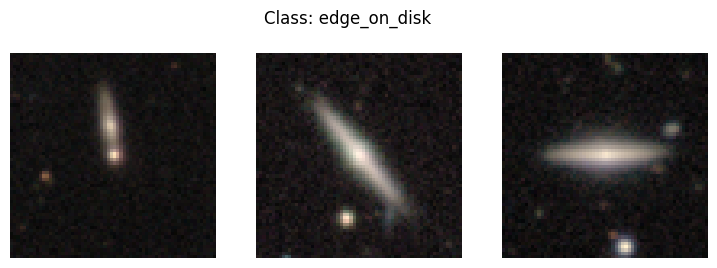

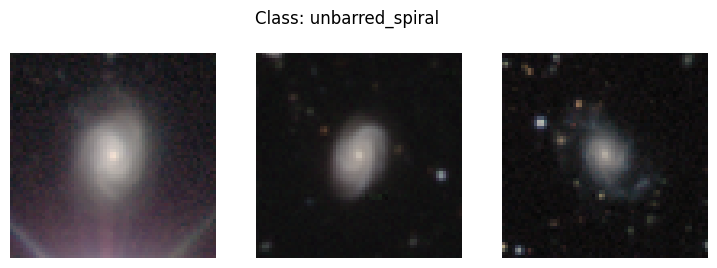

In [4]:
for i, name in enumerate(label_names):
    show_first_galaxies_of_class(3, raw_images[labels == i], name)

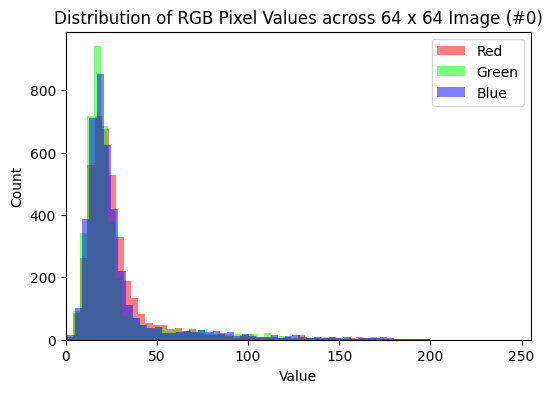

In [5]:
img_num = 0
rgb_values = raw_images[img_num].float()
color_names = ['Red','Green','Blue']
opacity = 0.5
color_rgb_vals = [(1, 0, 0, opacity), (0, 1, 0, opacity), (0, 0, 1, opacity)]

fig, ax = plt.subplots(figsize=(6,4))

for color, color_name, color_val in zip(rgb_values, color_names, color_rgb_vals):
    color = color.flatten()
    ax.hist(color.numpy(), bins=50, color=color_val, label=color_name)
ax.set_xlabel("Value")
ax.set_ylabel("Count")
ax.set_title(f'Distribution of RGB Pixel Values across 64 x 64 Image (#{img_num})')
ax.set_xlim((0, 255))
# ax.set_yscale('log')
ax.legend()
plt.show()

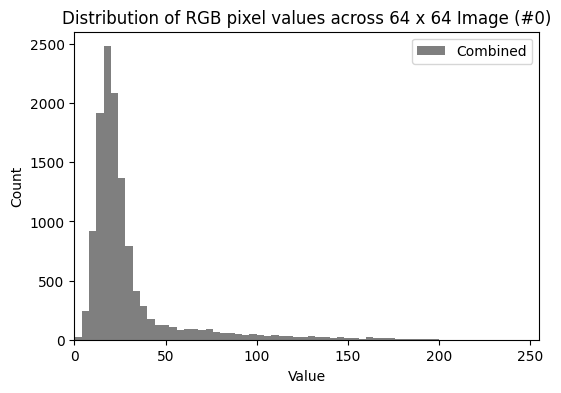

In [6]:
img_num = 0
values = raw_images[img_num].float().flatten()

fig, ax = plt.subplots(figsize=(6,4))
ax.hist(values.numpy(), bins=50, color='tab:grey', label='Combined')
ax.set_xlabel("Value")
ax.set_ylabel("Count")
ax.set_title(f'Distribution of RGB pixel values across 64 x 64 Image (#{img_num})')
ax.set_xlim((0, 255))
# ax.set_yscale('log')
ax.legend()
plt.show()

## 1.2 Standardization of Data

Many machine learning models require or assume the input data to be standardized, meaning to have mean 0 and variance 1. However, there are multiple ways to achieve this for our dataset.
- What are the possible ways to standardize the data? (There is more than one way, think about the dimensions of the data.)
- Which one would you pick? Explain in one sentence why you picked it.
- Perform the standardization and check it. (You won't need a loop to achieve this, but rather use `torch.mean` and `torch.std` with the correct dimensions specified.)

---

The data could be normalized along any of the axes, or any combination of them. However, only some of these make sense.
The shape of the dataset is $8000 \times 3 \times 64 \times 64$.
The R, G and B values could be normalized to their common mean/variance within each image (per-image and per-color normalization).
They could also be normalized to a mean across *all* images (dataset-wide normalization), or across all images for each color (separately $\rightarrow$ per-color normalization, or combined $\rightarrow$ per-image normalization).
It would not make sense to normalize row by row or column by column of an image, so we will not do this.

We feel it makes the most sense to normalize per-color over all images.
This will preserve information in the case that different galaxy types have different mean/variances of pixel values.

In [7]:
def normalize_over_axes(ds_imgs: torch.Tensor, axis: int | tuple[int, ...] | list[int] | torch.Size) -> torch.Tensor:
    x = ds_imgs.float()
    std_dev = x.std(dim=axis, keepdim=True)
    mean = x.mean(dim=axis, keepdim=True)
    z_score = (x - mean) / std_dev
    return z_score

axes_to_norm_over = (0, 2, 3)

print(f'Shape of raw data tensor: {raw_images.shape}')
print(f'Shape after doing mean: {raw_images.float().mean(axes_to_norm_over, keepdim=True).shape}')

normed_dataset = normalize_over_axes(raw_images, axes_to_norm_over)
normed_test_dataset = normalize_over_axes(raw_test_images, axes_to_norm_over)

Shape of raw data tensor: torch.Size([8000, 3, 64, 64])
Shape after doing mean: torch.Size([1, 3, 1, 1])


## 1.3 k-Nearest Neighbors
A typical way to classify data is to use the [k-Nearest Neighbors algorithm](https://en.wikipedia.org/wiki/K-nearest_neighbors_algorithm). In this task we will start with a simple implementation and evaluation and improve upon that.
### 1.3.1 Naive k-NN
- Implement a k-NN classifier using one loop over the test set and another loop over the training set. Do not use a third loop to compute the image distances, but rather use pytorch functions. You can use `tqdm` to show a progress bar for the outer loop to estimate the time it takes to classify the test set. If it would take too long, you can use a subset of the test set for this part.
- Bonus: Are there cases in which the classification criterion of k-nearest neighbors is ambiguous? Note what your implementation does in such cases.

---
We implement the Euclidean distance using a vectorized function which creates a matrix of distances $(d_{ij})_{i, j \in \mathbb{N}_0}$, where $i$ indexes the input data images and $j$ indexes the $8000$ training data images.
Next we implement a function which takes a list of distances to the training images for one vector and returns the most common label of the nearest $k$ training images.
Putting these together gives the `kNN_classify` function, which then returns a list of the determined labels, one for each input image.

It can be possible that more than one label is the most common (same occurrence number) for the $k$ nearest neighbors.
In this case, the `Counter.most_common(1)` method returns the element which occurs the most often starting from the beginning of the list.
This is shown in the example below.

This is the default behavior of this method, and it is acceptable and logical for the nearest neighbors method.
If there are the same number of different labels, the algorithm prefers the label which is more common closer to the test point.

In [8]:
from Part01.naive_kNN import get_most_common_entry, kNN_classify_batched

print(f'most common entry: {get_most_common_entry([0, 1])}')
print(f'most common entry: {get_most_common_entry([1, 0])}')
print(f'most common entry: {get_most_common_entry([0, 0, 0, 1, 1, 1])}')
print(f'most common entry: {get_most_common_entry([1, 1, 1, 0, 0, 0,])}')

most common entry: 0
most common entry: 1
most common entry: 0
most common entry: 1


In [9]:
training_size = None
test_size = 50
k = 3

true_labels = test_labels[:test_size]
st = time.time()
classification_labels = kNN_classify_batched(
    normed_test_dataset[:test_size],
    normed_dataset[:training_size],
    labels[:training_size],
    k = k,
    batch_size = 10,
    debug = True
)
et = time.time()
rt = et - st
print(f'Runtime = {rt}')
print(classification_labels)

total inputs to analyze: 50
total batches: 5


5it [00:06,  1.29s/it]

Runtime = 6.439333200454712
tensor([3., 1., 1., 0., 0., 2., 1., 2., 1., 3., 2., 3., 2., 2., 1., 1., 1., 0.,
        0., 1., 0., 2., 3., 3., 0., 3., 3., 0., 0., 0., 1., 1., 1., 3., 2., 2.,
        3., 0., 2., 2., 1., 1., 0., 0., 1., 3., 2., 0., 2., 3.])


### 1.3.2 Evaluation
Now that you have predictions, a meaningful way to evaluate the classifier is required.

- Read up on classification metrics. Describe the F1 score in one sentence. Why is it important to consider precision and recall together?
- Implement total accuracy (no loop needed). For reference, the accuracy achieved by your implementation with $k=3$ should be around $60\%$.
- Compare the results with sci-kit learns `sklearn.metric.classification_report`.
- Compute the confusion matrix. You may use [sklearn implementation](https://scikit-learn.org/dev/modules/generated/sklearn.metrics.ConfusionMatrixDisplay.html#sklearn.metrics.ConfusionMatrixDisplay.from_predictions). What do you observe?
- Do we have a class imbalance in the dataset? If there was a class imbalance, what is the flaw in using total accuracy as a metric? What are the possible ways to address this issue?

---



The total accuracy is defined as the following:
\begin{gather}
    a = \frac{\mathrm{TP} + \mathrm{TN}}{n} \\
    \mathrm{TP} : \text{True Positive} \\
    \mathrm{TN} : \text{True Negative} \\
    n : \text{Total classifications}
\end{gather}

In [10]:
def total_accuracy(labels: torch.Tensor, true_labels: torch.Tensor) -> float:
    '''Calculate the fraction of successful classifications divided by total number of classifications.'''
    # labels = torch.as_tensor(labels)
    # true_labels = torch.as_tensor(true_labels)
    successes = (labels == true_labels)
    summary = Counter(successes.tolist())
    return summary[True] / (summary[True] + summary[False])

print(f'Total accuracy of the classification of {test_size} images with k = {k} was: {total_accuracy(classification_labels, true_labels)}.')

Total accuracy of the classification of 50 images with k = 3 was: 0.78.


In [11]:
print(metrics.classification_report(true_labels, classification_labels))
print(metrics.confusion_matrix(true_labels, classification_labels))

              precision    recall  f1-score   support

           0       0.77      0.91      0.83        11
           1       0.64      0.82      0.72        11
           2       0.83      0.67      0.74        15
           3       0.91      0.77      0.83        13

    accuracy                           0.78        50
   macro avg       0.79      0.79      0.78        50
weighted avg       0.80      0.78      0.78        50

[[10  0  0  1]
 [ 0  9  2  0]
 [ 1  4 10  0]
 [ 2  1  0 10]]


In [12]:
print(f'Totals of different galaxy classes: (label, count):')
print(Counter(test_labels.tolist()).most_common())
print(Counter(test_labels[0:test_size].tolist()).most_common())

Totals of different galaxy classes: (label, count):
[(2, 507), (0, 507), (1, 506), (3, 480)]
[(2, 15), (3, 13), (1, 11), (0, 11)]


### 1.3.3 Faster k-NN
The double loop implementation computes all distances in sequence, which is slow. A faster way is to compute all distances at once using matrix operations.

- Implement a k-NN classifier that can compute distances between all test and training points at once either by using optimized distance computation functions by torch or scipy or similar libraries.
- Measure the run time of both implementations and write them down. For evaluation, we recommend using the classification report as well as the ConfusionMatrix from scikit-learn.

In [13]:
from Part01.fast_kNN import kNN_classify_fast

In [14]:
training_size = None
test_size = 200
k = 3

true_labels = test_labels[:test_size]
st = time.time()
classification_labels = kNN_classify_fast(
    normed_test_dataset[:test_size],
    normed_dataset[:training_size],
    labels[:training_size],
    k = k,
    debug=True
)
et = time.time()
rt_fast = et - st
print(f'Runtime: {rt_fast}')
print(classification_labels)

200it [00:00, 274.60it/s]

Runtime: 0.843066930770874
tensor([3., 1., 1., 0., 0., 2., 1., 2., 1., 3., 2., 3., 2., 2., 1., 1., 1., 0.,
        0., 1., 0., 2., 3., 3., 0., 3., 3., 0., 0., 0., 1., 1., 1., 3., 2., 2.,
        3., 0., 2., 2., 1., 1., 0., 0., 1., 3., 2., 0., 2., 3., 1., 2., 1., 1.,
        3., 2., 3., 3., 0., 0., 3., 0., 1., 2., 0., 2., 2., 0., 0., 1., 2., 0.,
        1., 2., 1., 3., 2., 1., 0., 1., 0., 0., 3., 0., 3., 1., 1., 2., 2., 1.,
        1., 3., 0., 1., 3., 0., 0., 1., 0., 1., 0., 3., 1., 3., 2., 2., 0., 2.,
        1., 3., 3., 3., 1., 1., 3., 0., 2., 1., 2., 3., 3., 1., 1., 1., 1., 0.,
        0., 0., 3., 1., 0., 1., 1., 1., 2., 3., 2., 2., 1., 2., 0., 1., 1., 2.,
        3., 2., 3., 2., 0., 0., 1., 0., 2., 0., 0., 0., 0., 2., 0., 2., 1., 2.,
        1., 0., 0., 0., 2., 1., 3., 1., 0., 0., 3., 3., 1., 0., 0., 0., 1., 0.,
        3., 0., 2., 1., 3., 1., 0., 3., 3., 0., 0., 1., 0., 0., 2., 3., 0., 2.,
        1., 0.])


In [15]:
print(metrics.classification_report(true_labels, classification_labels))
print(metrics.confusion_matrix(true_labels, classification_labels))

              precision    recall  f1-score   support

           0       0.79      0.96      0.86        50
           1       0.51      0.64      0.57        45
           2       0.67      0.52      0.58        54
           3       0.90      0.71      0.79        51

    accuracy                           0.70       200
   macro avg       0.72      0.71      0.70       200
weighted avg       0.72      0.70      0.70       200

[[48  1  0  1]
 [ 1 29 12  3]
 [ 2 24 28  0]
 [10  3  2 36]]


### 1.3.4 Hyperparameter tuning
An important part of machine learning is hyperparameter tuning. But it can sometimes be tedious to tune hyperparameters by hand through numerous experiments. Fortunately, k-NN only has one hyperparameter.
- Determine based on the accuracy which $k$ leads to the best classifier.
- Plot the accuracy against $k$.

In [22]:
def eval_accuracy(
    test_data,
    test_labels,
    training_data,
    training_labels,
    k,
):
    classification_labels = kNN_classify_fast(
        test_data,
        training_data,
        training_labels,
        k = k
    )
    return total_accuracy(classification_labels, test_labels)

test_size = 200
max_k = 15
ks = range(1, max_k+1)
accuracies = [eval_accuracy(normed_test_dataset[:test_size], test_labels[:test_size], normed_dataset, labels, k) for k in ks]

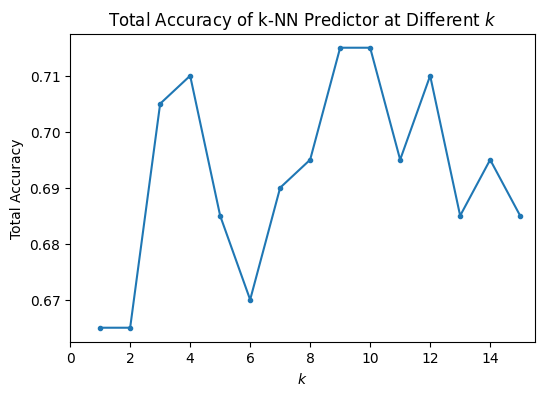

In [23]:
fig, ax = plt.subplots(figsize=(6,4))
ax.plot(ks, accuracies, marker='.')
ax.set_xlim((0, max_k+0.5))
ax.set_xlabel(r'$k$')
ax.set_ylabel(r'Total Accuracy')
ax.set_title(r'Total Accuracy of k-NN Predictor at Different $k$')
plt.show()

## 1.4 Exploiting Symmetries and Domain Knowledge
The standard k-Nearest Neighbor approach using Euclidean distance on galaxy images does not leverage any domain-specific knowledge about the data structure.

- **Identify Invariances**: What transformations can be applied to a galaxy image that preserve its class label? In other words, how can you transform an image while keeping it in the same class?

- **Distance Metric Design**: Propose modifications to the distance metric that would make it robust to these transformations. Explain your reasoning. (You don't need to implement this, just describe the approach theoretically.)

- **Data Preprocessing Strategy**: How could you preprocess the dataset to reduce the impact of these transformations on classification? Consider alignment, normalization, or feature extraction approaches.

- **Bonus Implementation Challenge**: Implement one of your proposed approaches and evaluate whether it outperforms the baseline Euclidean distance metric!


---

Because we know that a galaxy class does not depend on viewing angle/rotation, we should be able to rotate images by 90°. Reflections should also be possible.
Because galaxies can be closer or further away, their brightnesses can vary.
However, this should not change the classification of the galaxy, so we should be able to boost/reduce brightness of an image and it should still be classified the same.

Distance metric

Although it increases the risk of overfitting, we could reflect and rotate galaxies and adopt these into the training data as well. This would give us $(4 \cdot 4) = 16$ times as many training images ($4$ rotations and $4$ reflections from the $D_4$ group).